# PLEA — rating tables

Visual companion to `scripts/build_plea.py`. Nothing here is the source of
truth: every number comes from `plfootball`, and this notebook only displays it.

Run `python scripts/build_plea.py` first if `data/processed/` is empty.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from plfootball import config, ingest, plea

pd.set_option("display.max_rows", 120)

results = ingest.load_results()
history = plea.run(results)

print(f"{len(results):,} matches   {results['date'].min():%b %Y} to {results['date'].max():%b %Y}")
print(f"{len(history):,} rating rows   PLEA {plea.DEFAULT.version}")

6,080 matches   Aug 2010 to May 2026
12,160 rating rows   PLEA v1


---
## Current ratings

Latest available. `active_only=True` keeps the clubs playing in the most recent
season — turn it off to see every club that has ever played, each frozen at the
rating it left the league on.

In [2]:
current = plea.ratings_as_of(history)
current.style.format({"elo": "{:.1f}", "last_match": "{:%d %b %Y}"}).bar(
    subset=["elo"], color="#8FB9B5", vmin=1250, vmax=1780
)

,team,elo,last_match,played
rank,,,,
1,Arsenal,1729.3,24 May 2026,38
2,Manchester City,1705.2,24 May 2026,38
3,Manchester United,1619.1,24 May 2026,38
4,Liverpool,1599.8,24 May 2026,38
5,Bournemouth,1579.5,24 May 2026,38
6,Aston Villa,1575.4,24 May 2026,38
7,Brighton and Hove Albion,1538.8,24 May 2026,38
8,Brentford,1532.1,24 May 2026,38
9,Chelsea,1524.7,24 May 2026,38


### Ratings on any past date

The table is a query against the history, so "what did it look like then" is
just a different date. This is the same call the model uses to fetch a club's
rating before a match.

In [3]:
snapshot = plea.ratings_as_of(history, "2022-03-01")
snapshot.head(10).style.format({"elo": "{:.1f}", "last_match": "{:%d %b %Y}"})

,team,elo,last_match,played
rank,,,,
1,Manchester City,1754.6,26 Feb 2022,27
2,Liverpool,1730.2,23 Feb 2022,26
3,Chelsea,1659.7,19 Feb 2022,25
4,Arsenal,1612.8,24 Feb 2022,24
5,Manchester United,1607.7,26 Feb 2022,27
6,West Ham United,1567.2,27 Feb 2022,27
7,Tottenham Hotspur,1556.6,26 Feb 2022,25
8,Wolverhampton Wanderers,1524.1,27 Feb 2022,26
9,Leicester City,1504.5,20 Feb 2022,23


---
## Season-end tables

Where every club finished, season by season.

In [4]:
seasons = sorted(history["season"].unique())

for season in seasons[-4:]:  # change the slice to see more
    table = plea.season_end_table(history, season)
    print(f"\n{'=' * 46}\n  {config.season_label(season)}\n{'=' * 46}")
    print(table.assign(elo=table["elo"].round(1)).to_string())


  2022/23
                          team     elo
rank                                  
1              Manchester City  1781.6
2                      Arsenal  1667.8
3                    Liverpool  1667.8
4             Newcastle United  1618.4
5            Manchester United  1616.4
6                  Aston Villa  1566.4
7                    Brentford  1565.5
8     Brighton and Hove Albion  1559.8
9            Tottenham Hotspur  1547.4
10                     Chelsea  1486.9
11              Crystal Palace  1481.2
12                      Fulham  1475.3
13             West Ham United  1462.4
14     Wolverhampton Wanderers  1438.6
15              Leicester City  1435.1
16                     Everton  1418.9
17           Nottingham Forest  1409.6
18                 Bournemouth  1380.0
19                Leeds United  1361.6
20                 Southampton  1328.2

  2023/24
                          team     elo
rank                                  
1              Manchester City  1802.6
2  

### Every season at once

Clubs down the side, seasons across the top. Blank means the club wasn't in the
division that year — which is most of what promotion and relegation looks like
from the model's point of view.

In [5]:
grid = (
    pd.concat(
        [plea.season_end_table(history, s).assign(season=s) for s in seasons],
        ignore_index=True,
    )
    .pivot(index="team", columns="season", values="elo")
    .rename(columns=config.season_label)
)

grid = grid.loc[grid.notna().sum(axis=1).sort_values(ascending=False).index]
grid.style.format("{:.0f}", na_rep="").background_gradient(cmap="BuGn", axis=None)

season,2010/11,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24,2024/25,2025/26
team,,,,,,,,,,,,,,,,
Arsenal,1582,1612,1650,1655,1678,1646,1650,1586,1595,1574,1596,1596,1668,1741,1700,1729
Liverpool,1556,1515,1580,1699,1582,1569,1639,1673,1778,1780,1678,1778,1668,1695,1717,1600
Manchester City,1597,1716,1669,1747,1710,1616,1671,1793,1816,1746,1741,1782,1782,1803,1698,1705
Tottenham Hotspur,1554,1588,1630,1582,1566,1622,1725,1702,1614,1583,1578,1633,1547,1556,1445,1440
Manchester United,1642,1705,1722,1615,1625,1597,1636,1678,1584,1636,1657,1550,1616,1557,1460,1619
Everton,1540,1567,1587,1617,1511,1484,1553,1493,1535,1482,1504,1429,1419,1474,1519,1494
Chelsea,1607,1564,1644,1700,1714,1576,1724,1616,1612,1585,1601,1634,1487,1580,1607,1525
West Ham United,1400,,1442,1440,1437,1547,1472,1459,1491,1453,1559,1525,1462,1469,1456,1457
Newcastle United,1482,1543,1430,1419,1393,1422,,1448,1475,1447,1461,1511,1618,1576,1591,1521


---
## Rating trajectories

Sixteen seasons of every rating change. The sawtooth at each season boundary is
the carry-over rule pulling clubs back towards 1500; the gaps are relegation.

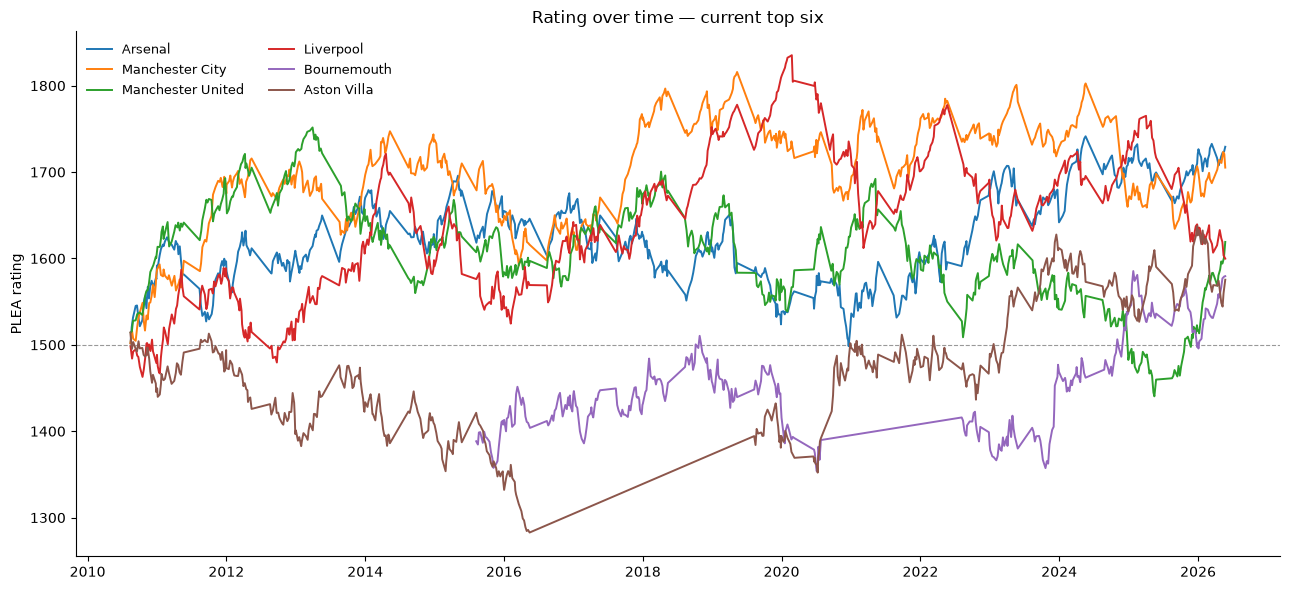

In [6]:
top = plea.ratings_as_of(history).head(6)["team"].tolist()

fig, ax = plt.subplots(figsize=(13, 6))
for team in top:
    run = history[history["team"] == team].sort_values("date")
    ax.plot(run["date"], run["elo_after"], linewidth=1.4, label=team)

ax.axhline(1500, color="#999", linewidth=0.8, linestyle="--", zorder=0)
ax.set_ylabel("PLEA rating")
ax.set_title("Rating over time — current top six")
ax.legend(loc="upper left", fontsize=9, ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

---
## Is PLEA calibrated?

The test that matters before any of this feeds a model: when PLEA says a club
should take 0.65 of the points, do they? Points on the diagonal mean the
expectation is honest.

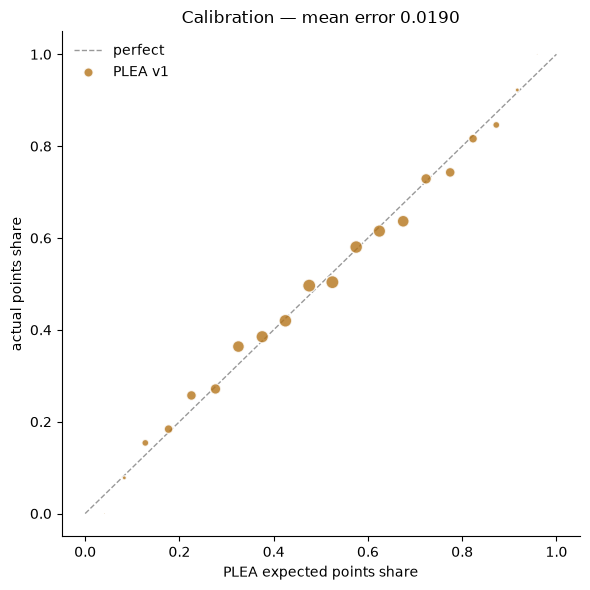

In [7]:
buckets = pd.cut(history["elo_expected"], [i / 20 for i in range(21)])
cal = history.groupby(buckets, observed=True).agg(
    n=("actual", "size"),
    predicted=("elo_expected", "mean"),
    actual=("actual", "mean"),
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color="#999", linestyle="--", linewidth=1, label="perfect")
ax.scatter(cal["predicted"], cal["actual"], s=cal["n"] / 12, color="#B4741A",
           alpha=0.8, edgecolor="white", zorder=3, label="PLEA v1")

ax.set_xlabel("PLEA expected points share")
ax.set_ylabel("actual points share")
ax.set_title(f"Calibration — mean error {(cal['predicted'] - cal['actual']).abs().mean():.4f}")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

### Home advantage, by era

PLEA v1 assumes 65 rating points of home advantage. This is what the matches
actually show — and it is not one number.

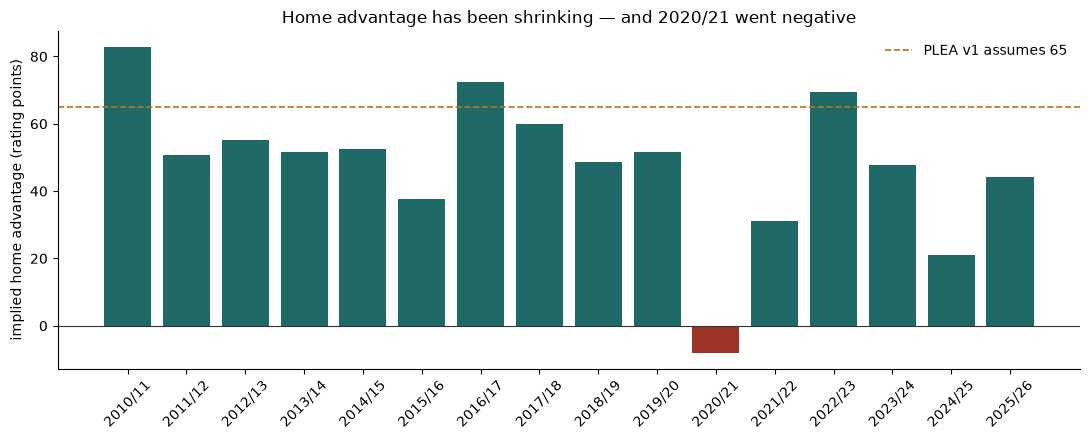

In [8]:
import numpy as np

home = history[history["is_home"] == 1]
by_season = home.groupby("season")["actual"].mean()
implied = 400 * np.log10(by_season / (1 - by_season))

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["#9C3527" if v < 20 else "#1F6A67" for v in implied]
ax.bar([config.season_label(s) for s in implied.index], implied.values, color=colors)
ax.axhline(65, color="#B4741A", linestyle="--", linewidth=1.2, label="PLEA v1 assumes 65")
ax.axhline(0, color="#333", linewidth=0.8)
ax.set_ylabel("implied home advantage (rating points)")
ax.set_title("Home advantage has been shrinking — and 2020/21 went negative")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()